In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# **Load Data**

In [191]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


In [192]:
df.shape

(4269, 13)

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [194]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# **Data Cleaning**

**Handling Missing Values**

In [195]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


**Removing Duplicates**

In [196]:
df.duplicated().sum()

np.int64(0)

**Removing the spaces in Column name**

In [197]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [198]:
df.columns = df.columns.str.strip()

In [199]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

**Reduce Columns**

In [200]:
df.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


In [201]:
df['assets'] = df['residential_assets_value'] + df['commercial_assets_value'] + df['luxury_assets_value'] + df['bank_asset_value']

In [202]:
df.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,assets
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,50700000
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,17000000
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,57700000


In [203]:
df.drop(columns = ['loan_id', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'], inplace=True)

In [204]:
df.head(3)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,assets
0,2,Graduate,No,9600000,29900000,12,778,Approved,50700000
1,0,Not Graduate,Yes,4100000,12200000,8,417,Rejected,17000000
2,3,Graduate,No,9100000,29700000,20,506,Rejected,57700000


# **Data Preprocessing**

**Perform Encoding**

In [205]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [206]:
df['education'].value_counts()

,count
education,
Graduate,2144
Not Graduate,2125


In [207]:
df['loan_status'].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


In [208]:
df['self_employed'].value_counts()

,count
self_employed,
Yes,2150
No,2119


In [209]:
df['education'] = le.fit_transform(df['education']) # 0 --> Graduate, 1 --> Not Graduate
df['loan_status'] = le.fit_transform(df['loan_status']) # 0 --> Approved, 1 --> Rejected
df['self_employed'] = le.fit_transform(df['self_employed']) # 0 --> No, 1 --> Yes

In [210]:
df.head(3)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,assets
0,2,0,0,9600000,29900000,12,778,0,50700000
1,0,1,1,4100000,12200000,8,417,1,17000000
2,3,0,0,9100000,29700000,20,506,1,57700000


# **Input Output Selection**

In [211]:
x = df.drop(columns = ['loan_status'])
y = df['loan_status']

# **Scaling**

In [212]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [213]:
x = scaler.fit_transform(x)

In [214]:
x

array([[-0.2941017 , -0.99555917, -1.00728821, ...,  0.19261651,
         1.03279241,  0.93062813],
       [-1.4735476 ,  1.00446064,  0.99276452, ..., -0.50809068,
        -1.06105118, -0.79719794],
       [ 0.29562125, -0.99555917, -1.00728821, ...,  1.59403089,
        -0.54484044,  1.28952375],
       ...,
       [-0.2941017 ,  1.00446064, -1.00728821, ...,  1.2436773 ,
        -0.82904635,  0.33075973],
       [-0.88382465,  1.00446064, -1.00728821, ..., -0.50809068,
         1.04439265, -0.19220246],
       [-0.88382465, -0.99555917, -1.00728821, ..., -0.15773708,
         0.04097176,  2.29443149]])

# **Sampling**

In [215]:
y.value_counts()

,count
loan_status,
0,2656
1,1613


In [216]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler()

In [217]:
x, y = ros.fit_resample(x, y)

In [218]:
y.value_counts()

,count
loan_status,
0,2656
1,2656


# **Splitting Data into Training and Testing**

In [219]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [220]:
x_train.shape, y_train.shape

((4249, 8), (4249,))

In [221]:
x_test.shape, y_test.shape

((1063, 8), (1063,))

In [222]:
y_train.value_counts()

,count
loan_status,
1,2125
0,2124


In [223]:
y_test.value_counts()

,count
loan_status,
0,532
1,531


# **Training Model**

In [224]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=1000)

In [225]:
LR.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

# **Model Evaluation**

**Overfitting Check**

In [226]:
LR.score(x_train, y_train), LR.score(x_test, y_test)

(0.9197458225464815, 0.9379115710253998)

**Model Performance Check**

In [227]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score

y_pred = LR.predict(x_test)

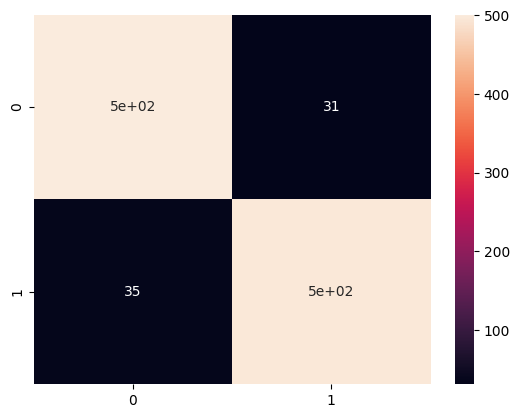

In [228]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.show()

In [229]:
auc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print("Accuracy Score :", auc)
print("F1 Score :", f1)
print("Recall Score :", recall)
print("Precision Score :", precision)

Accuracy Score : 0.9379115710253998
F1 Score : 0.9376181474480151
Recall Score : 0.9340866290018832
Precision Score : 0.9411764705882353


# **Perform Prediction**

In [230]:
df.head(3)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,assets
0,2,0,0,9600000,29900000,12,778,0,50700000
1,0,1,1,4100000,12200000,8,417,1,17000000
2,3,0,0,9100000,29700000,20,506,1,57700000


In [232]:
input_data = pd.DataFrame({'no_of_dependents': [2],	'education': [0],	'self_employed': [0],	'income_annum': [9600000],
                           'loan_amount': [29900000],	'loan_term': [12],	'cibil_score': [778],	'assets': [50700000]})

In [233]:
scaled_input = scaler.transform(input_data)

In [234]:
prediction = LR.predict(scaled_input)

In [235]:
probabilities = LR.predict_proba(scaled_input)

if prediction[0] == 0:
  print("Loan Approved")
  print(f"Confidence: {round(probabilities[0][0]*100,2)}%")
else:
  print("Loan Rejected")
  print(f"Confidence: {round(probabilities[0][1]*100,2)}%")

Loan Approved
Confidence: 99.55%


# **Save Model and Required Objects**

In [236]:
import pickle as pkl

pkl.dump(LR, open('model.pkl', 'wb'))
pkl.dump(scaler, open('scaler.pkl', 'wb'))